<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/notebooks/age_prediction_eda_regression_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Age Prediction: data preparation, Exploratory Data Analysis (EDA), and regression with cross-validation (CV) & nested CV

## Data Preparation and Exploratory Data Analysis (EDA)

Import libraries

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Loading and showing input (features) and output data (desired output)

In [ ]:
df = pd.read_excel('https://raw.githubusercontent.com/sdiciotti/Age-Prediction-Demo/main/NKI2_data.xlsx')
print (type(df))

<class 'pandas.core.frame.DataFrame'>


Print the size of the dataframe

In [ ]:
df.shape

(73, 35)

Print the dataframe

In [ ]:
print(df)

    Age Sex  cortex_CT  lh_cortex_CT  rh_cortex_CT  lh_frontalGM_CT  \
0    13   F   2.563765       2.53793       2.58960            2.604   
1    13   M   2.816775       2.80403       2.82952            2.870   
2    16   F   2.590785       2.60300       2.57857            2.659   
3    17   M   2.618340       2.62847       2.60821            2.780   
4    17   M   2.737575       2.77298       2.70217            2.866   
..  ...  ..        ...           ...           ...              ...   
68   14   F   2.785335       2.80093       2.76974            2.956   
69   16   M   2.645850       2.62908       2.66262            2.793   
70   12   F   2.731690       2.73606       2.72732            2.854   
71   10   F   2.674965       2.67007       2.67986            2.749   
72   11   M   2.733215       2.74924       2.71719            2.846   

    lh_occipitalGM_CT  lh_temporalGM_CT  lh_parietalGM_CT  rh_frontalGM_CT  \
0               2.084             2.694             2.432            

Check the features and output variables name

In [ ]:
features = list(df.columns)
type(features)

list

In [ ]:
print(features)

['Age', 'Sex', 'cortex_CT', 'lh_cortex_CT', 'rh_cortex_CT', 'lh_frontalGM_CT', 'lh_occipitalGM_CT', 'lh_temporalGM_CT', 'lh_parietalGM_CT', 'rh_frontalGM_CT', 'rh_occipitalGM_CT', 'rh_temporalGM_CT', 'rh_parietalGM_CT', 'cortex_pial_lgi', 'lh_cortex_pial_lgi', 'rh_cortex_pial_lgi', 'lh_frontal_pial_lgi', 'lh_occipital_pial_lgi', 'lh_temporal_pial_lgi', 'lh_parietal_pial_lgi', 'rh_frontal_pial_lgi', 'rh_occipital_pial_lgi', 'rh_temporal_pial_lgi', 'rh_parietal_pial_lgi', 'cerebralGM_FD', 'lh_cerebralGM_FD', 'lh_frontalGM_FD', 'lh_temporalGM_FD', 'lh_parietalGM_FD', 'lh_occipitalGM_FD', 'rh_cerebralGM_FD', 'rh_frontalGM_FD', 'rh_temporalGM_FD', 'rh_parietalGM_FD', 'rh_occipitalGM_FD']


Plotting some data

Text(0, 0.5, 'cortex CT (mm)')

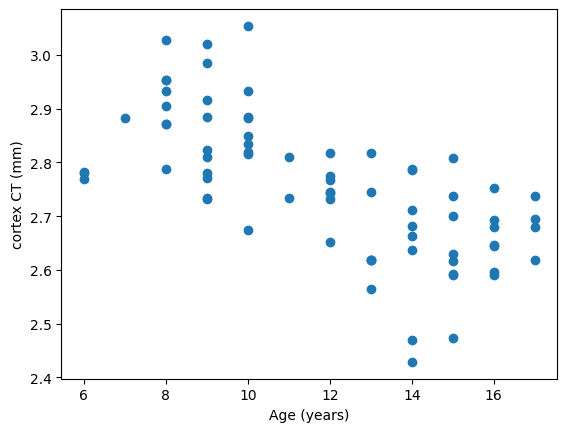

In [ ]:
# Plot true vs predicted values to visualize model performance
plt.scatter(df['Age'],df['cortex_CT'])
plt.xlabel('Age (years)')
plt.ylabel('cortex CT (mm)')

In [ ]:
print("Dataframe shape before NaN removal:", df.shape)

Dataframe shape before NaN removal: (73, 35)


Removing missing data

In [ ]:
df.dropna(axis=0, how='any', inplace=True)
print("Dataframe shape after NaN removal:", df.shape)

Dataframe shape after NaN removal: (72, 35)


Preparing the design matrix X and the desired output y

In [ ]:
X = df.iloc[:,2::]
y = df['Age']
print (type(X))
print (type(y))
print (X.shape)
print (y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(72, 33)
(72,)


A quick quality control

In [ ]:
X.head(6)

,cortex_CT,lh_cortex_CT,rh_cortex_CT,lh_frontalGM_CT,lh_occipitalGM_CT,lh_temporalGM_CT,lh_parietalGM_CT,rh_frontalGM_CT,rh_occipitalGM_CT,rh_temporalGM_CT,...,lh_cerebralGM_FD,lh_frontalGM_FD,lh_temporalGM_FD,lh_parietalGM_FD,lh_occipitalGM_FD,rh_cerebralGM_FD,rh_frontalGM_FD,rh_temporalGM_FD,rh_parietalGM_FD,rh_occipitalGM_FD
0,2.563765,2.53793,2.58960,2.604,2.084,2.694,2.432,2.573,2.213,2.901,...,2.4527,2.3947,2.3795,2.3840,2.2441,2.4524,2.4001,2.3942,2.3788,2.2650
1,2.816775,2.80403,2.82952,2.870,2.265,3.188,2.564,2.914,2.244,3.230,...,2.4719,2.4216,2.4228,2.3896,2.2861,2.5181,2.4290,2.4202,2.3942,2.2631
2,2.590785,2.60300,2.57857,2.659,2.058,2.877,2.537,2.649,2.083,2.787,...,2.4854,2.3733,2.3712,2.3852,2.2485,2.4820,2.3681,2.3633,2.3735,2.2511
3,2.618340,2.62847,2.60821,2.780,2.057,2.867,2.459,2.739,2.129,2.880,...,2.4911,2.4034,2.3956,2.3679,2.2631,2.4535,2.3933,2.3921,2.3683,2.2677
4,2.737575,2.77298,2.70217,2.866,2.137,3.194,2.546,2.716,2.204,3.150,...,2.5081,2.4224,2.4194,2.3738,2.2687,2.4641,2.4074,2.4158,2.3694,2.2728
5,2.752830,2.76857,2.73709,2.825,2.172,3.129,2.593,2.702,2.308,3.185,...,2.5024,2.4062,2.4273,2.3702,2.2810,2.4618,2.3929,2.4225,2.3780,2.3053


In [ ]:
print('The whole dataset contains ' + str(X.shape[0]) + ' subjects')
print('The age prediction will be performed using ' + str(X.shape[1]) + ' MRI-derived features')

The whole dataset contains 72 subjects
The age prediction will be performed using 33 MRI-derived features


## Regression task

### Linear regression using a CV scheme

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate, KFold
from sklearn.svm import SVR

# Setting the seed of the random generator
SEED = 42

# Setting the number of folds
n_folds = 5

# Creating the estimator
#reg = LinearRegression()
reg = SVR(kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=1, epsilon=0.1, shrinking=True, cache_size=200, verbose=0, max_iter=- 1)

# Creating the splitter
cv = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)

In [ ]:
# Print the generated splits
for train_index, test_index in cv.split(X):
    print("Train:", train_index, " Test:", test_index)

Train: [ 1  2  3  6  7  8 11 13 14 15 16 17 19 20 21 22 23 24 25 26 27 29 30 32
 33 35 36 37 38 39 40 41 42 43 44 46 48 49 51 52 53 55 56 57 58 59 60 61
 63 64 65 66 67 68 69 70 71]  Test: [ 0  4  5  9 10 12 18 28 31 34 45 47 50 54 62]
Train: [ 0  1  2  3  4  5  6  8  9 10 11 12 13 14 15 17 18 19 20 21 23 24 25 26
 27 28 29 31 32 34 36 37 38 40 41 43 45 47 48 50 51 52 53 54 57 58 60 61
 62 63 64 65 66 67 68 70 71]  Test: [ 7 16 22 30 33 35 39 42 44 46 49 55 56 59 69]
Train: [ 0  1  2  4  5  7  9 10 11 12 14 15 16 18 20 21 22 23 24 26 27 28 29 30
 31 32 33 34 35 37 39 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 59
 60 61 62 63 65 66 67 68 69 70]  Test: [ 3  6  8 13 17 19 25 36 38 40 57 58 64 71]
Train: [ 0  1  2  3  4  5  6  7  8  9 10 12 13 14 16 17 18 19 20 21 22 23 25 28
 29 30 31 33 34 35 36 37 38 39 40 42 43 44 45 46 47 49 50 51 52 54 55 56
 57 58 59 60 62 63 64 67 69 71]  Test: [11 15 24 26 27 32 41 48 53 61 65 66 68 70]
Train: [ 0  3  4  5  6  7  8  9 10 11 12 13 15 16 17 18 

In [ ]:
score = cross_validate(reg, X=X, y=y, cv=cv, return_train_score=True, scoring = 'neg_mean_absolute_error')

print("This is the score object:")
print (score)

print("Average MAE training set:", np.mean(np.abs(score['train_score'])), "years")
print("Average MAE tes set:", np.mean(np.abs(score['test_score'])), "years")

This is the score object:
{'fit_time': array([0.00544095, 0.00240922, 0.00222588, 0.00216961, 0.00219631]), 'score_time': array([0.00279427, 0.00172901, 0.00178647, 0.00174284, 0.00180531]), 'test_score': array([-1.96516495, -1.69834222, -1.47619532, -1.3528025 , -2.07928787]), 'train_score': array([-1.51757213, -1.72181049, -1.69668166, -1.70997242, -1.56123815])}
Average MAE training set: 1.6414549705947792 years
Average MAE tes set: 1.7143585706462816 years


In [ ]:
print(type(score))
print(type(score['train_score']))

<class 'dict'>
<class 'numpy.ndarray'>


### Support Vector Regression with hyperparameter C (Complexity) using a nested CV scheme

In [ ]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

# Setting the seed of the random generator
SEED = 42

# Setting the number of folds of both outer and inner k-fold CV
outer_n_folds = 5
inner_n_folds = 5

# Setting the possible values of the C hyperparameter
C = [0.1, 1, 10]

# Creating the splitters
outer_cv = KFold(n_splits=outer_n_folds, shuffle=True, random_state=SEED)
inner_cv = KFold(n_splits=inner_n_folds, shuffle=True, random_state=SEED)

# Creating the estimator
reg = SVR(kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=0.1, epsilon=0.1, shrinking=True, cache_size=200, verbose=0, max_iter=-1)

# Defining the grid of hyperparameter values
p_grid = [{'C': C}]

reg_gs = GridSearchCV(reg, param_grid=p_grid, cv=inner_cv, refit='neg_mean_absolute_error', scoring='neg_mean_absolute_error', verbose = 4)
nested_score = cross_validate(reg_gs, X=X, y=y, cv=outer_cv, return_train_score=True, return_estimator=True, scoring = 'neg_mean_absolute_error')

#print(np.abs(nested_score['train_score']))
#print(np.abs(nested_score['test_score']))
print("Average MAE train:", np.abs(np.mean(nested_score['train_score'])), "years")
print("Average MAE test:", np.abs(np.mean(nested_score['test_score'])), "years")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV 1/5] END ............................C=0.1;, score=-2.315 total time=   0.0s
[CV 2/5] END ............................C=0.1;, score=-1.942 total time=   0.0s
[CV 3/5] END ............................C=0.1;, score=-2.458 total time=   0.0s
[CV 4/5] END ............................C=0.1;, score=-3.115 total time=   0.0s
[CV 5/5] END ............................C=0.1;, score=-3.355 total time=   0.0s
[CV 1/5] END ..............................C=1;, score=-1.614 total time=   0.0s
[CV 2/5] END ..............................C=1;, score=-1.297 total time=   0.0s
[CV 3/5] END ..............................C=1;, score=-1.571 total time=   0.0s
[CV 4/5] END ..............................C=1;, score=-2.337 total time=   0.0s
[CV 5/5] END ..............................C=1;, score=-2.101 total time=   0.0s
[CV 1/5] END .............................C=10;, score=-1.444 total time=   0.0s
[CV 2/5] END .............................C=10;, 

In [ ]:
print(type(p_grid))
print(type(p_grid[0]))

<class 'list'>
<class 'dict'>
